In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [6]:
df = pd.read_csv('Carbon_(CO2)_Emissions_by_Country.csv')
df

,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita
0,Afghanistan,Asia,01-01-2011,8930.0,0.31
1,Afghanistan,Asia,01-01-2012,8080.0,0.27
2,Afghanistan,Asia,01-01-2010,7110.0,0.25
3,Afghanistan,Asia,01-01-2019,6080.0,0.16
4,Afghanistan,Asia,01-01-2018,6070.0,0.17
...,...,...,...,...,...
5672,Zimbabwe,Africa,01-01-2004,9770.0,0.80
5673,Zimbabwe,Africa,01-01-2007,9760.0,0.78
5674,Zimbabwe,Africa,01-01-2010,9600.0,0.75
5675,Zimbabwe,Africa,01-01-2009,7750.0,0.61


In [7]:
df.head()

,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita
0,Afghanistan,Asia,01-01-2011,8930.0,0.31
1,Afghanistan,Asia,01-01-2012,8080.0,0.27
2,Afghanistan,Asia,01-01-2010,7110.0,0.25
3,Afghanistan,Asia,01-01-2019,6080.0,0.16
4,Afghanistan,Asia,01-01-2018,6070.0,0.17


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5677 entries, 0 to 5676
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 5677 non-null   object 
 1   Region                  5677 non-null   object 
 2   Date                    5677 non-null   object 
 3   Kilotons of Co2         5677 non-null   float64
 4   Metric Tons Per Capita  5677 non-null   float64
dtypes: float64(2), object(3)
memory usage: 221.9+ KB


In [9]:
df.describe()

,Kilotons of Co2,Metric Tons Per Capita
count,5.677000e+03,5677.000000
mean,1.412292e+05,4.325505
std,6.491258e+05,5.503834
min,0.000000e+00,0.000000
25%,1.380000e+03,0.570000
50%,9.170000e+03,2.360000
75%,5.848000e+04,6.340000
max,1.070722e+07,47.650000


In [16]:
df.columns

Index(['Country', 'Region', 'Year', 'Kilotons of Co2',
       'Metric Tons Per Capita'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
Country,0
Region,0
Date,0
Kilotons of Co2,0
Metric Tons Per Capita,0


In [19]:
df['Year'] = pd.to_datetime(df['Year']).dt.year
df = df[['Country','Region','Year','Kilotons of Co2','Metric Tons Per Capita']]
df = df.dropna()
df.head()

,Country,Region,Year,Kilotons of Co2,Metric Tons Per Capita
0,Afghanistan,Asia,1970,8930.0,0.31
1,Afghanistan,Asia,1970,8080.0,0.27
2,Afghanistan,Asia,1970,7110.0,0.25
3,Afghanistan,Asia,1970,6080.0,0.16
4,Afghanistan,Asia,1970,6070.0,0.17


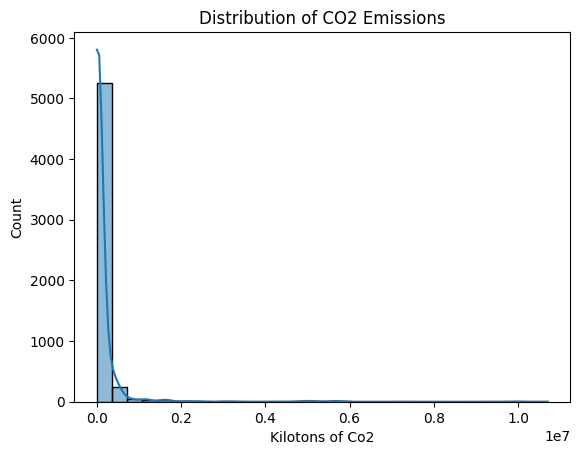

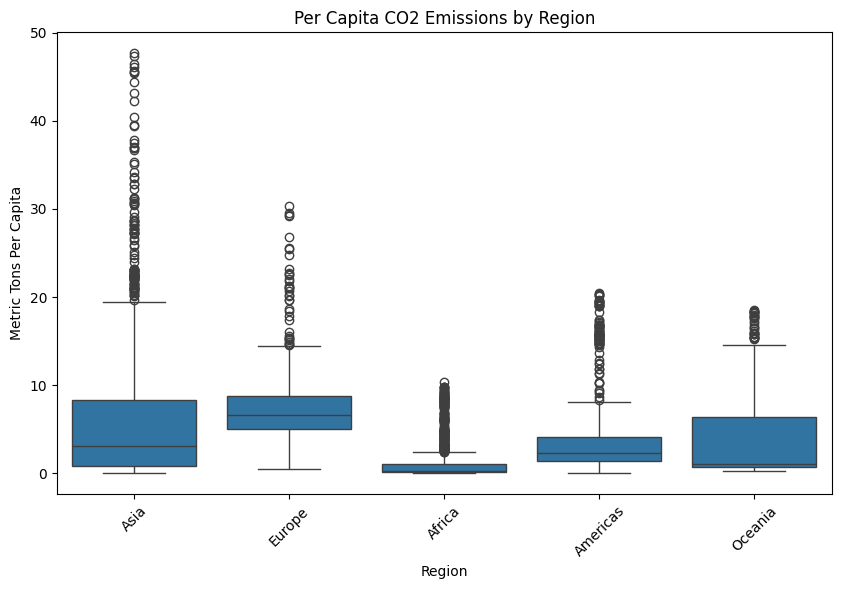

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of CO2 emissions
sns.histplot(df['Kilotons of Co2'], bins=30, kde=True)
plt.title("Distribution of CO2 Emissions")
plt.show()

# Compare regions
plt.figure(figsize=(10,6))
sns.boxplot(x='Region', y='Metric Tons Per Capita', data=df)
plt.xticks(rotation=45)
plt.title("Per Capita CO2 Emissions by Region")
plt.show()


In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features
X = df[['Kilotons of Co2','Metric Tons Per Capita']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster centers
print("Cluster Centers (scaled):\n", kmeans.cluster_centers_)


Cluster Centers (scaled):
 [[-0.13533301 -0.33425981]
 [ 0.1756152   1.77667684]
 [14.63608291  0.49093164]
 [ 7.4326909   1.6187812 ]]


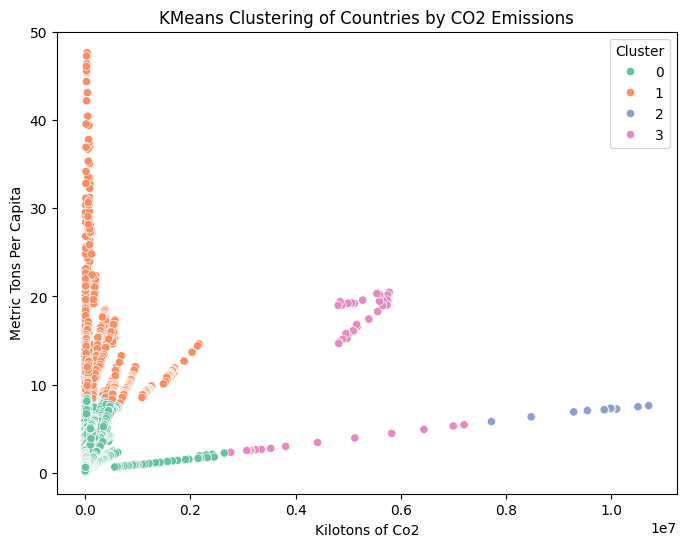

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Kilotons of Co2', y='Metric Tons Per Capita',
                hue='Cluster', data=df, palette='Set2')
plt.title("KMeans Clustering of Countries by CO2 Emissions")
plt.show()


In [23]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)


Silhouette Score: 0.6666401086621544
